## Model Evaluation
This notebook evaluates the pretrained and finetuned DeepForest models and compares them both quantitatively and qualitatively.

### 1. Setup

In [22]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["NO_ALBUMENTATIONS_UPDATE"] = "1"
os.environ["MASTER_PORT"] = "29500"
os.environ["MASTER_ADDR"] = "localhost"
os.environ['TRANSFORMERS_OFFLINE'] = '1'
os.environ['HF_DATASETS_OFFLINE'] = '1'

In [15]:
import torch.multiprocessing as mp
mp.set_start_method('spawn', force=True) 

from glob import glob
from tqdm import tqdm

import random
import pandas as pd
import numpy as np
import torch
import torchvision

torch.set_float32_matmul_precision('medium') 

from deepforest import main
from deepforest import preprocess
from deepforest import evaluate as df_eval
from deepforest.visualize import plot_results

In [16]:
torch.cuda.is_available(), torch.cuda.device_count()

(True, 2)

We write a helper function to load the pretrained model (from Hugging face or model weights).

In [17]:
from deepforest import main, utilities

PT_FILE = "../resources/NEON.pt"

def load_model(checkpoint_dict_path):
    # ── 1. Load bundled config (local only, no network) ───────────────────────────
    cfg = utilities.load_config()

    # ── 2. Build architecture with ZERO downloads ─────────────────────────────────
    #   weights=None      → no COCO RetinaNet download
    #   weights_backbone=None → no ResNet-50 ImageNet download  ← the missing piece
    model = torchvision.models.detection.retinanet_resnet50_fpn(
        weights=None,
        weights_backbone=None,
        num_classes=cfg.num_classes,
        score_thresh=cfg.score_thresh,
        nms_thresh=cfg.nms_thresh,
    )

    # ── 3. Load NEON.pt weights ───────────────────────────────────────────────────
    checkpoint = torch.load(checkpoint_dict_path, map_location="cpu", weights_only=False)
    state_dict = checkpoint.get("state_dict", checkpoint)

    # Strip legacy "model." prefix if present (same logic as RetinaNetHub's hook)
    state_dict = {
        k.replace("model.", "", 1) if k.startswith("model.") else k: v
        for k, v in state_dict.items()
    }
    model.load_state_dict(state_dict)
    model.eval()

    # ── 4. Set attributes deepforest's predict_tile expects on self.model ─────────
    model.label_dict = dict(cfg.label_dict)
    model.num_classes = cfg.num_classes
    model.nms_thresh  = cfg.nms_thresh
    model.score_thresh = cfg.score_thresh
    
    # ── 5. Wrap in deepforest (model != None → skips create_model() entirely) ─────
    m = main.deepforest(model=model, config_args={"model": {"name": None}})
    m.label_dict = dict(cfg.label_dict)
    m.numeric_to_label_dict = {v: k for k, v in cfg.label_dict.items()}

    return m

We had split the data into training and validation splits. So we now load the validation split to use in evaluating the models.

In [18]:
csv_file = "../sample_data/annotations/master_val.csv"
root_dir = "../all_chips"

### 2. Quantitative Comparison
#### 2.1 Evaluating the Pretrained Model
We first run an evaluation of the pretrained model on the validation set. The metrics of interest are `box precision`, `box_recall`, and `mean IoU`.
To do that, we will have to load the pretrained model weights.

In [19]:
model = load_model(PT_FILE)
print("Pretrained model loaded ...\n")

# ------------------------------------------------------------------ #
# 2. Evaluate Pretrained Model
# ------------------------------------------------------------------ #
print("Starting pretrained model evaluation ...\n")
results = model.evaluate(
    csv_file=csv_file,
    root_dir=root_dir,
    iou_threshold=0.4
)
print("..............................................")
print("Pretrained Model Evaluation Results Computed")
print("..............................................")

pretrained_df = pd.DataFrame({
    "Metric": ["Box Precision", "Box Recall", "Mean IoU"],
    "Pretrained": [
        results["box_precision"],
        results["box_recall"],
        results['results'][results['results']['IoU'] > 0.4].IoU.mean()
    ],
})
pretrained_df.to_csv("pretrained_results.csv", index=False)
print("Results of pretrained model evaluation saved ...")

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
SLURM auto-requeueing enabled. Setting signal handlers.


Pretrained model loaded ...

Starting pretrained model evaluation ...



Predicting: |          | 0/? [00:00<?, ?it/s]

..............................................
Pretrained Model Evaluation Results Computed
..............................................
Results of pretrained model evaluation saved ...


#### 2.2 Evaluating the Finetuned Model
Next, we run an evaluation of the finetuned model on the validation set. The metrics of interest are `box precision`, `box_recall`, and `mean IoU`.

We load the model weights from the last checkpoint saved during the finetuning process

In [23]:
# ------------------------------------------------------------------ #
# 3. Load Finetuned Model
# ------------------------------------------------------------------ #
ckpt_path = "../resources/deepforest-epoch=72-val_loss=0.6651.ckpt"
finetuned_model = main.deepforest.load_from_checkpoint(checkpoint_path=ckpt_path, pretrained=False, patch_predict_weights=False)
print("Checkpoint loaded ...\n")


# ------------------------------------------------------------------ #
# 4. Evaluate Finetuned Model
# ------------------------------------------------------------------ #
print("Starting finetuned model evaluation ...\n")
res_finetuned = finetuned_model.evaluate(
    csv_file=csv_file,
    root_dir=root_dir,
    iou_threshold=0.4
)
print("..............................................")
print("Finetuned Model Evaluation Results Computed")
print("..............................................")

finetuned_df = pd.DataFrame({
    "Metric": ["Box Precision", "Box Recall", "Mean IoU"],
    "Finetuned": [
        res_finetuned["box_precision"],
        res_finetuned["box_recall"],
        res_finetuned['results'][res_finetuned['results']['IoU'] > 0.4].IoU.mean()
    ]
})
finetuned_df.to_csv("finetuned_results.csv", index=False)
print("Results of finetuned model evaluation saved ...")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer(limit_val_batches=1.0)` was configured so 100% of the batches will be used..
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /weecology/deepforest-tree/resolve/main/config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno -2] Name or service not known)"))'), '(Request ID: 500875ab-c51a-4b4d-87b4-4616cea0220c)')' thrown while requesting HEAD https://huggingface.co/weecology/deepforest-tree/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded wi

Checkpoint loaded ...

Starting finetuned model evaluation ...



Predicting: |          | 0/? [00:00<?, ?it/s]

..............................................
Finetuned Model Evaluation Results Computed
..............................................
Results of finetuned model evaluation saved ...


The results have been saved. Here is how they look:

|Metric|Finetuned|Pretrained|
|------|---------|----------|
|Box Precision|0.2321746708967644|0.027673925868110797|
|Box Recall|0.8964174983701492|0.20525875154567988|
|Mean IoU|0.7271822389698513|0.5795117022999828|

As you can see, there has been significant improvement on finetuning. We shall now turn our attention  to qualitative comparison

### 3. Quantitative Comparison
It's nice to have numbers that show improvement in the performance, but it is even better when those numbers translate to a visible improvement in the tree crown detection. 

We will load an image and run an inference on the finetuned model using it and visually inspect the results.

In [32]:
import cv2
from matplotlib import pyplot as plt
from PIL import Image
path = "../sample_data/images/2025_02_16.png"
img = cv2.imread(path)[:,:,::-1]

#### 3.1 Finetuned Model
Let's begin with the finetuned model.

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
SLURM auto-requeueing enabled. Setting signal handlers.


Predicting: |          | 0/? [00:00<?, ?it/s]

985 predictions in overlapping windows, applying non-max suppression
978 predictions kept after non-max suppression
No image path provided, root_dir will be None, since either images were directly provided or there were multiple image paths


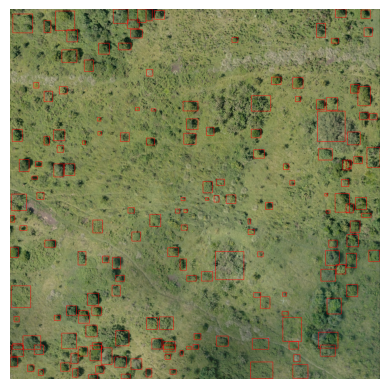

In [29]:
res = finetuned_model.predict_tile(image=img, patch_size=400, patch_overlap=0.0, iou_threshold=0.4)
ax = plot_results(res[res['score'] >= 0.35], axes=True, results_color=[0, 0, 255], thickness=4, image=Image.fromarray(img))

In [30]:
fig = ax.get_figure()
fig.savefig("finetuned_detections.png", dpi=1200)

#### 3.2 Pretrained Model
Let's do the same on the pretrained model

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
SLURM auto-requeueing enabled. Setting signal handlers.


Predicting: |          | 0/? [00:00<?, ?it/s]

2686 predictions in overlapping windows, applying non-max suppression
2633 predictions kept after non-max suppression
No image path provided, root_dir will be None, since either images were directly provided or there were multiple image paths


<Figure size 640x480 with 0 Axes>

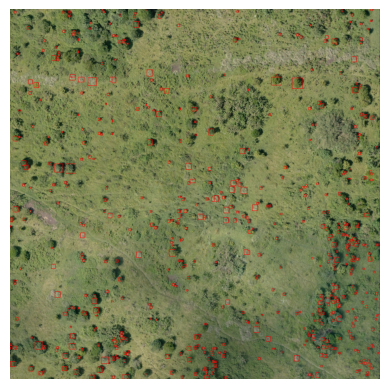

In [34]:
res = model.predict_tile(image=img, patch_size=400, patch_overlap=0.0, iou_threshold=0.4)
plt.tight_layout()
ax = plot_results(res[res['score'] >= 0.35], axes=True, results_color=[0, 0, 255], thickness=4, image=Image.fromarray(img))
plt.show()

In [35]:
fig = ax.get_figure()
fig.savefig("pretrained_detections.png", dpi=1200)

#### 3.3 Side by Side Comparison
We can see that the performance of the pretrained model was so much worse before finetuning. Let's put them side by side.

In [37]:
paths = ["finetuned_detections.png", "pretrained_detections.png"]
f_img = cv2.imread(paths[0])[:,:,::-1]
p_img = cv2.imread(paths[1])[:,:,::-1]

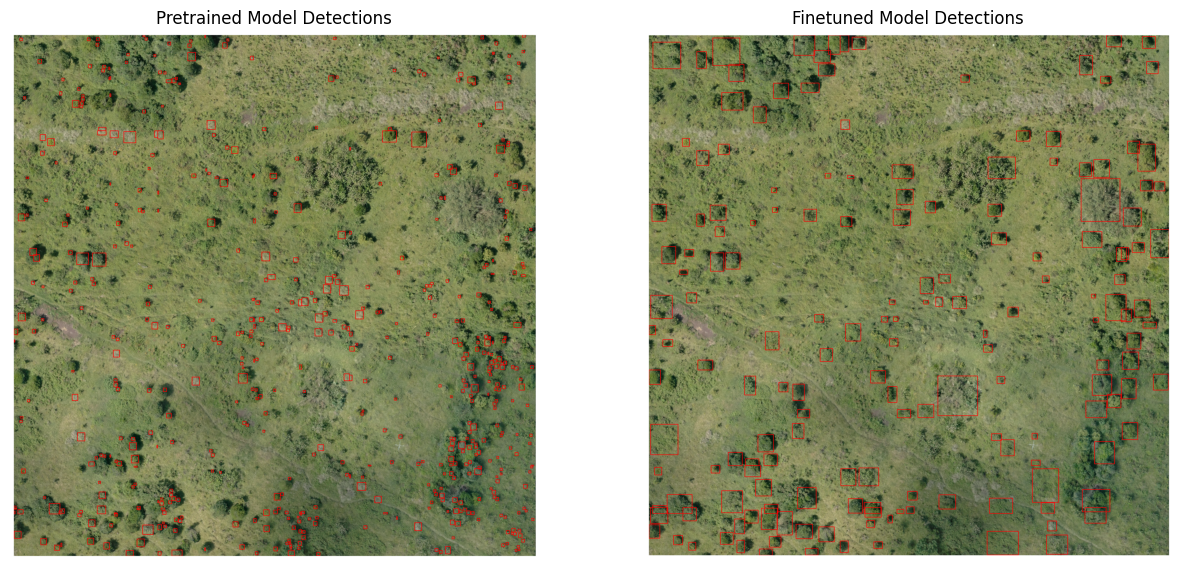

In [43]:
plt.figure(figsize=(15, 8))
plt.subplot(121), plt.imshow(p_img), plt.title("Pretrained Model Detections"), plt.axis("off")
plt.subplot(122), plt.imshow(f_img), plt.title("Finetuned Model Detections"), plt.axis("off")
plt.savefig("both_detections.png", bbox_inches="tight", dpi=600)
plt.show()

The difference is much clearer with the two images side by side. With the finetuned model, we can see that the detection bounding boxes latch more accurately around the trees and the model also successfully ignores the smaller objects in the image, which are shrubs rather than trees. 